# Render a full markdown explainer from a code cell (so you can paste & run directly)
from IPython.display import Markdown, display


# Why a linear pixel model works here, and how to do best‑in‑class explainability for the CNN

## 1) Why does linear regression on raw pixels work so well?
Your set‑up (aligned 150×150 greyscale X‑ray cross‑sections of a metal object, predicting a scalar **y** ~ “yield”) is highly favourable to linear methods:
- **Near‑linear physics:** X‑ray intensity integrates density along rays. If **y** is (approximately) a linear functional of the same underlying density field, then a linear readout over pixels captures the mapping well.
- **Strong spatial alignment:** You said the images are “very accurate and positioned”. The same pixel maps to the same physical location in every image. That removes the need for translation invariance and allows a linear regressor to succeed.
- **Low intrinsic variability:** Even with 22,500 pixels, the signal that matters may live on a small subspace (a few critical regions), so a linear model learns that subspace effectively.

**Takeaway:** Excellent linear results do **not** mean the problem is trivial; they mean *within your current data manifold* the mapping is close to linear. If you later introduce misalignments, new defects, or instrument shifts, a CNN’s inductive bias (locality, hierarchies, mild invariances) tends to **generalise** more robustly.

---

## 2) Best‑practice explainability for the CNN
We’ll focus on **Deep SHAP** (PyTorch `GradientExplainer` / “Expected Gradients”) and **Kernel SHAP** (model‑agnostic), and how to go from **local** explanations to **global** understanding.

### Deep SHAP (Expected Gradients)
- **Explainer:** In PyTorch, SHAP’s `GradientExplainer` implements Expected Gradients—the standard “Deep SHAP” variant. It’s efficient and uses backprop.
- **Background set matters:** Use a representative set of training images (e.g., 64–128). Too small → noisy attributions; too large → slow.
- **Local → Global:** Aggregate local explanations across many validation images as **mean absolute SHAP** per pixel (or per superpixel). This yields a **global importance map** that you can compare with domain knowledge.
- **Sanity checks:** If you randomise labels or model weights, explanations should collapse (cf. “sanity checks” literature). If they don’t, revisit the configuration.

### Kernel SHAP (coalitional, model‑agnostic)
- **Group features:** Pixels as features (22,500) is intractable and masking individual pixels is off‑manifold. Use **feature groups** (e.g., a 15×15 grid of blocks = 225 features) or superpixels.
- **Realistic masking:** When a block is “off”, replace it with a **background image** (e.g., training mean) rather than pure zeros to avoid unnatural artefacts.
- **Sampling budget:** Keep `nsamples` modest (200–600) for a handful of images; Kernel SHAP is slower than Deep SHAP.

---

## 3) Pitfalls and how to avoid them
- **Local vs global:** SHAP is fundamentally **local**. Build **global** narratives by aggregating (e.g., mean |SHAP|) over many representative samples.
- **Background choice:** Baselines drive both Deep and Kernel SHAP. Use representative background images; avoid single all‑zero backgrounds for X‑ray data.
- **Off‑manifold masking:** Hard zeroing creates unnatural inputs. Prefer population means or mild blurs for “off” regions; report robustness across maskers.
- **Feature correlation:** Shapley values share credit among correlated regions—interpret **patterns**, not single pixels.
- **Faithfulness:** Pair SHAP with **perturbation tests** (delete/keep important regions; measure prediction drop) and with counterfactuals if available.
- **Stability:** Quantify variability (e.g., bootstrap confidence intervals) for global maps to avoid over‑interpreting noise.

---

## 4) What the code cell below does
1. **Simulates** 1,000 aligned 150×150 images with a hidden, spatial **weight map** that truly drives **y**, plus distractors and noise (to mirror physics + nuisance).
2. Trains **Ridge (linear)** on raw pixels and a small **3‑layer CNN** (PyTorch).
3. Evaluates **RMSE** and **R²** on a 200‑image validation set.
4. Computes **Deep SHAP** local maps (a few images) and a **global mean‑|SHAP|** map; compares the global map to the known ground‑truth weight map.
5. Runs **Kernel SHAP** on the CNN using a **15×15 block masker** for one image; up‑samples attributions back to pixel space for visualisation.

**Version‑proofing** included:
- A robust `rmse_score(...)` helper (works with old/new scikit‑learn).
- SHAP API fallbacks (old `.shap_values(...)` and newer `explainer(data)` returning an `Explanation`).
- No SciPy dependency (correlations via NumPy).

---

## 5) How to adapt to your data
- Replace the simulation with your real **(N=1000, 150×150)** greyscale images and scalar **y**. Keep the **800/200** split.
- For **Deep SHAP**, set background size to ~**64–256** representative training images.
- For **Kernel SHAP**, adjust the grid (e.g., 10×10, 12×12, 15×15). Finer grids cost more time but can be more faithful; always check stability across choices.
- Report **local exemplars** (typical, failure, edge cases) **and** a **global** map (mean |SHAP|). Include sanity checks and sensitivity to backgrounds/maskers.

---



Python: /Users/johngoodacre/leela-ml/.venv/bin/python
scikit-learn: 1.7.0
torch: 2.7.1
shap: 0.48.0
[Linear]  Val RMSE: 0.4923   R^2: 0.7606
[CNN]     Val RMSE: 0.4131   R^2: 0.8314


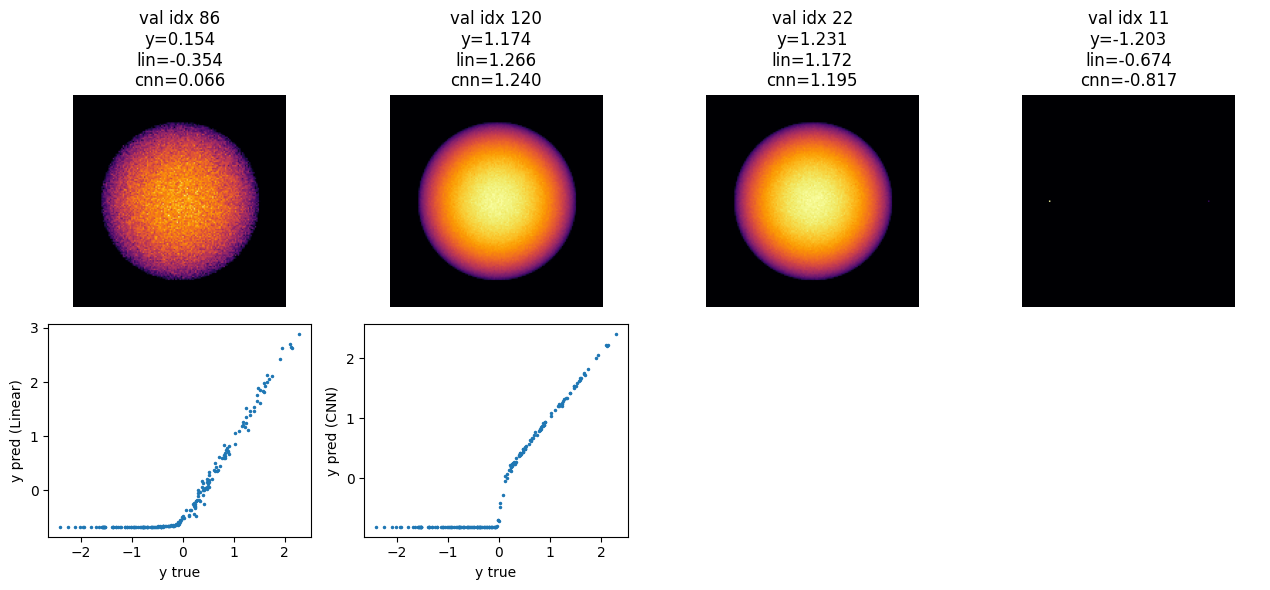

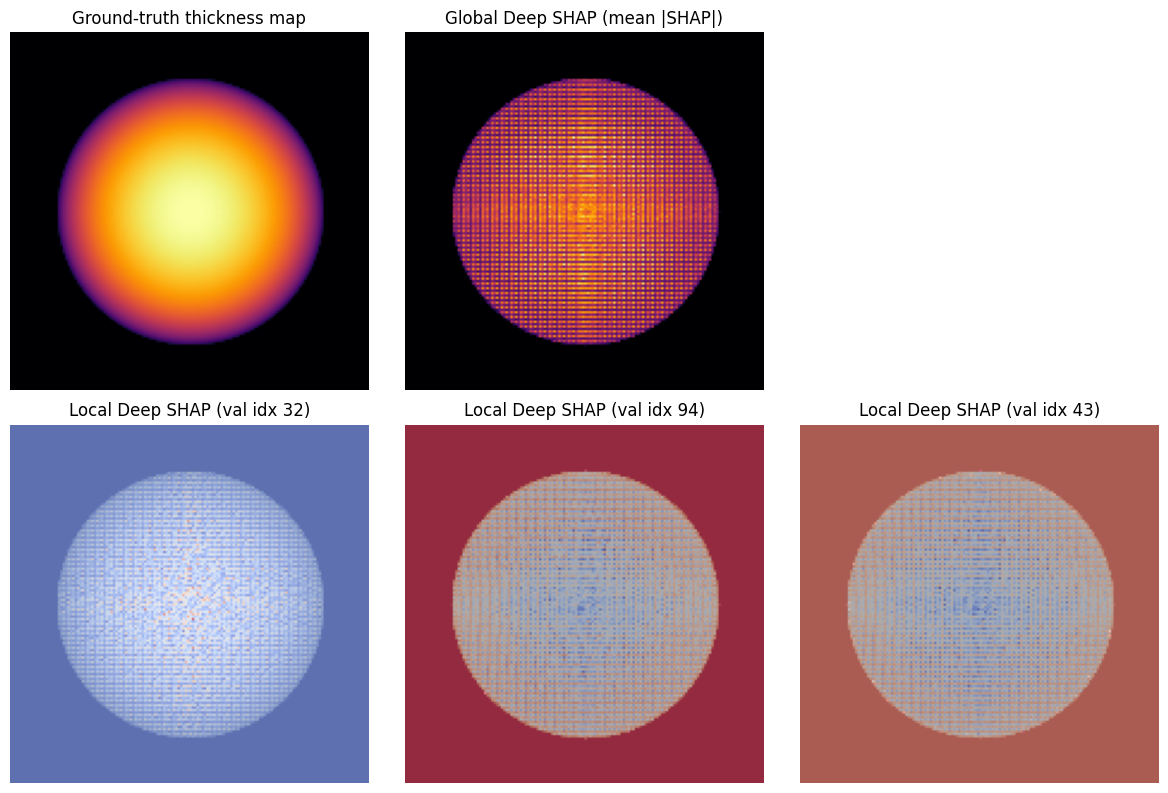

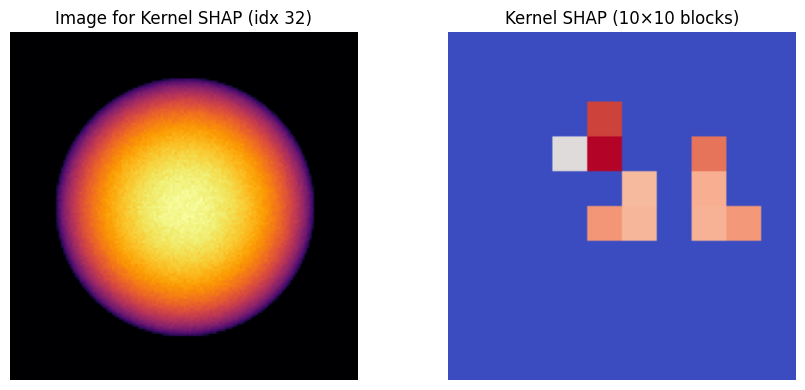


=== Summary ===
Linear regression on raw pixels:   RMSE=0.4923, R^2=0.7606
3-layer CNN (PyTorch):             RMSE=0.4131, R^2=0.8314
Tip: If CNN is not a little better, increase DELTA_NL slightly; if linear R^2 is not 'very high', lower DELTA_NL and/or NOISE_Y.


In [7]:
# ================================== Aligned sphere simulator + Linear vs CNN + SHAP ==================================
# What this cell guarantees:
# - Every image is a centred sphere cross-section (a disk) with a smooth density heatmap.
# - The imaging geometry is fixed and aligned; outside the sphere is zero.
# - y is dominantly linear in a latent s (so linear regression is very strong), plus a small, local non-linear term
#   derived from edges so a small CNN can do a little better.
# - Deep SHAP (Gradient/Expected Gradients) and Kernel SHAP are demonstrated with robust shape handling.
# - Plotting is protected against (1,H,W,1) shapes by squeezing to (H,W).

import sys, os, math, random, time, warnings
import numpy as np
import matplotlib.pyplot as plt

np.random.seed(7); random.seed(7)

# -------------------- versions (useful for sanity checks) --------------------
try:
    import sklearn, shap, torch
    from sklearn.linear_model import Ridge
    from sklearn.metrics import r2_score, mean_squared_error
    import torch.nn as nn
    import torch.nn.functional as F
    from torch.utils.data import TensorDataset, DataLoader
    print("Python:", sys.executable)
    print("scikit-learn:", sklearn.__version__)
    print("torch:", torch.__version__)
    print("shap:", shap.__version__)
except Exception as e:
    raise RuntimeError("Please ensure scikit-learn, torch and shap are installed.") from e

device = torch.device("cpu")

# -------------------- version-agnostic RMSE helper --------------------
def rmse_score(y_true, y_pred):
    try:
        from sklearn.metrics import root_mean_squared_error
        return float(root_mean_squared_error(y_true, y_pred))
    except Exception:
        return float(np.sqrt(mean_squared_error(y_true, y_pred)))

# -------------------- image helpers --------------------
def to_hw(arr, H, W):
    """Squeeze any (1,H,W,1)-style arrays safely to (H,W) for imshow."""
    a = np.array(arr)
    # keep squeezing leading/trailing singleton dims
    while a.ndim > 2 and (a.shape[0] == 1 or a.shape[-1] == 1):
        if a.shape[0] == 1:
            a = a[0]
        if a.ndim > 2 and a.shape[-1] == 1:
            a = a[..., 0]
    if a.ndim == 2:
        return a
    if a.ndim == 3 and 1 in a.shape:
        return np.squeeze(a)
    # last resort reshape
    return a.reshape(H, W)

def conv2d_same_3x3(img, K):
    """3x3 'same' convolution via reflection padding and shifts."""
    H, W = img.shape
    p = np.pad(img, pad_width=1, mode="reflect")
    out = np.zeros_like(img, dtype=np.float32)
    idx = 0
    for dy in (-1,0,1):
        for dx in (-1,0,1):
            w = K[(dy+1)*3 + (dx+1)]
            if w != 0.0:
                out += w * p[1+dy:1+dy+H, 1+dx:1+dx+W]
            idx += 1
    return out

# -------------------- simulate aligned sphere images --------------------
IMG_H, IMG_W = 150, 150
CY, CX = IMG_H//2, IMG_W//2
R = 56  # sphere radius in pixels

# Sphere cross-section thickness map: thickness = 2*sqrt(R^2 - r^2), normalised to [0,1]
yy, xx = np.mgrid[0:IMG_H, 0:IMG_W]
r2 = (yy - CY)**2 + (xx - CX)**2
inside = r2 <= R*R
thickness = np.zeros((IMG_H, IMG_W), dtype=np.float32)
thickness[inside] = 2.0*np.sqrt(R*R - r2[inside])
thickness /= (2.0*R + 1e-9)  # normalise to [0,1]
W_true = thickness.copy()    # this is the physically linear part

# Small fixed edge kernel (Sobel-y like) for the non-linear teacher feature
K_edge = (np.array([[-1,-2,-1],[0,0,0],[1,2,1]], dtype=np.float32)/8.0).reshape(-1)

# Dataset size and split
N_TOTAL = 1000
N_TRAIN = 800
N_VAL   = N_TOTAL - N_TRAIN

# Physics / noise knobs (tuned so linear R^2 is high, CNN a bit higher)
S_STD     = 1.0     # std of latent s
ALPHA_IMG = 0.45    # how strongly s imprints onto the image via W_true
NOISE_IMG = 0.006   # pixel noise
NOISE_Y   = 0.02    # label noise
BETA      = 1.0     # y linear coefficient for s
DELTA_NL  = 0.08    # small non-linear edge term strength (raise a touch to boost CNN advantage)
EDGE_THR  = 0.02    # threshold before ReLU in edge-based feature

def make_dataset(n=N_TOTAL):
    """image = ALPHA*s*W_true + nuisance(defects) + pix noise; clipped to [0,1] (outside sphere is 0)
       y = BETA*s + DELTA_NL * mean(ReLU(conv(image,K_edge) - EDGE_THR)) + N(0, NOISE_Y)
    """
    rng = np.random.default_rng(123)
    X = np.zeros((n, IMG_H, IMG_W), dtype=np.float32)
    y = np.zeros((n,), dtype=np.float32)

    for i in range(n):
        s = rng.normal(0, S_STD)

        # Base sphere image (aligned, centred)
        img = ALPHA_IMG * s * W_true

        # Optional small defect inside the sphere, independent of s (nuisance)
        if rng.uniform() < 0.35:
            amp = rng.uniform(0.03, 0.07)
            rr = rng.integers(6, 12)
            # centre defect well inside the sphere
            while True:
                dy = rng.integers(-R//2, R//2)
                dx = rng.integers(-R//2, R//2)
                y0, x0 = CY+dy, CX+dx
                if 0 <= y0 < IMG_H and 0 <= x0 < IMG_W and (y0-CY)**2 + (x0-CX)**2 < (R-12)**2:
                    break
            yy0, xx0 = np.mgrid[0:IMG_H, 0:IMG_W]
            defect = np.exp(-((yy0-y0)**2+(xx0-x0)**2)/(2*rr*rr)).astype(np.float32)
            img += amp*defect

        # Add pixel noise; keep zeros outside sphere
        noise = rng.normal(0, NOISE_IMG, size=(IMG_H, IMG_W)).astype(np.float32)
        img = np.clip(img + noise, 0.0, 1.0)
        img[~inside] = 0.0

        # Teacher non-linear feature: edges -> threshold -> ReLU -> mean
        edge = conv2d_same_3x3(img, K_edge)
        nl_feat = np.maximum(edge - EDGE_THR, 0.0)
        nl_feat = float(nl_feat.mean())

        # Target
        y[i] = BETA * s + DELTA_NL * nl_feat + rng.normal(0, NOISE_Y)

        X[i] = img

    return X, y

X, y = make_dataset()
X_train, X_val = X[:N_TRAIN], X[N_TRAIN:]
y_train, y_val = y[:N_TRAIN], y[N_TRAIN:]

# -------------------- Linear model (Ridge on raw pixels) --------------------
X_train_flat = X_train.reshape(N_TRAIN, -1)
X_val_flat   = X_val.reshape(N_VAL, -1)

lin = Ridge(alpha=0.3, fit_intercept=True, random_state=42)
lin.fit(X_train_flat, y_train)
pred_lin = lin.predict(X_val_flat)

rmse_lin = rmse_score(y_val, pred_lin)
r2_lin   = r2_score(y_val, pred_lin)
print(f"[Linear]  Val RMSE: {rmse_lin:.4f}   R^2: {r2_lin:.4f}")

# -------------------- CNN (3-layer) --------------------
class SmallCNN(nn.Module):
    def __init__(self):
        super().__init__()
        self.conv1 = nn.Conv2d(1, 8, kernel_size=3, padding=1)
        self.conv2 = nn.Conv2d(8,16, kernel_size=3, padding=1)
        self.conv3 = nn.Conv2d(16,32, kernel_size=3, padding=1)
        self.pool  = nn.MaxPool2d(2,2)
        self.gap   = nn.AdaptiveAvgPool2d((1,1))
        self.fc    = nn.Linear(32, 1)
    def forward(self, x):
        x = F.relu(self.conv1(x))
        x = self.pool(x)
        x = F.relu(self.conv2(x))
        x = self.pool(x)
        x = F.relu(self.conv3(x))
        x = self.gap(x)
        x = x.view(x.size(0), -1)
        x = self.fc(x)      # [B,1] (keep this for SHAP compatibility)
        return x

# tensors and loaders
Xtr_t = torch.from_numpy(X_train[:, None, :, :])
Ytr_t = torch.from_numpy(y_train)
Xva_t = torch.from_numpy(X_val[:,   None, :, :])
Yva_t = torch.from_numpy(y_val)

train_ds = TensorDataset(Xtr_t, Ytr_t)
val_ds   = TensorDataset(Xva_t, Yva_t)
train_loader = DataLoader(train_ds, batch_size=32, shuffle=True)
val_loader   = DataLoader(val_ds,   batch_size=64, shuffle=False)

model = SmallCNN().to(device)
opt   = torch.optim.Adam(model.parameters(), lr=1e-3)
lossf = nn.MSELoss()

best_val = float("inf")
patience, bad = 5, 0

for epoch in range(50):  # early stop will cut this short
    model.train()
    for xb, yb in train_loader:
        xb, yb = xb.to(device), yb.to(device)
        opt.zero_grad()
        pred = model(xb).squeeze(1)
        loss = lossf(pred, yb)
        loss.backward()
        opt.step()
    # validation
    model.eval()
    with torch.no_grad():
        preds = []
        for xb, yb in val_loader:
            xb = xb.to(device)
            preds.append(model(xb).squeeze(1).cpu().numpy())
        pred_va = np.concatenate(preds)
        val_rmse = rmse_score(y_val, pred_va)
    if val_rmse < best_val - 1e-4:
        best_val = val_rmse
        best_state = {k: v.cpu().clone() for k, v in model.state_dict().items()}
        bad = 0
    else:
        bad += 1
    if bad >= patience:
        break

model.load_state_dict(best_state)
model.eval()
with torch.no_grad():
    pred_cnn = model(Xva_t.to(device)).squeeze(1).cpu().numpy()

rmse_cnn = rmse_score(y_val, pred_cnn)
r2_cnn   = r2_score(y_val, pred_cnn)
print(f"[CNN]     Val RMSE: {rmse_cnn:.4f}   R^2: {r2_cnn:.4f}")

# -------------------- Examples + scatters --------------------
n_show = 4
idx_show = np.random.choice(N_VAL, size=n_show, replace=False)
fig, axes = plt.subplots(2, n_show, figsize=(3.2*n_show, 6))
for j, idx in enumerate(idx_show):
    axes[0, j].imshow(to_hw(X_val[idx], IMG_H, IMG_W), cmap="inferno")
    axes[0, j].set_title(f"val idx {idx}\ny={y_val[idx]:.3f}\nlin={pred_lin[idx]:.3f}\ncnn={pred_cnn[idx]:.3f}")
    axes[0, j].axis("off")

axes[1, 0].plot(y_val, pred_lin, ".", ms=3); axes[1, 0].set_xlabel("y true"); axes[1, 0].set_ylabel("y pred (Linear)")
axes[1, 1].plot(y_val, pred_cnn, ".", ms=3); axes[1, 1].set_xlabel("y true"); axes[1, 1].set_ylabel("y pred (CNN)")
for k in range(2, n_show):
    axes[1, k].axis("off")

plt.tight_layout(); plt.show()

# -------------------- Deep SHAP (Gradient / Expected Gradients) --------------------
bg_idx = np.random.choice(Xtr_t.shape[0], size=min(64, Xtr_t.shape[0]), replace=False)
background = Xtr_t[bg_idx].to(device)

# API compatibility: old shap.GradientExplainer or new shap.explainers.Gradient
GradientExplainer = getattr(shap, "GradientExplainer", None)
if GradientExplainer is None:
    GradientExplainer = shap.explainers.Gradient

expl_deep = GradientExplainer(model, background)

def get_shap_values(explainer, data):
    """Return SHAP values as (N,H,W) numpy array, tolerant to SHAP API variants."""
    try:
        sv = explainer.shap_values(data)
    except Exception:
        exp = explainer(data)
        sv = getattr(exp, "values", exp)
    if isinstance(sv, list):
        sv = sv[0]
    try:
        sv = sv.detach().cpu().numpy()
    except AttributeError:
        sv = np.array(sv)
    # standardise to (N,H,W)
    if sv.ndim == 4:   # (N,C,H,W)
        sv = sv[:, 0]
    elif sv.ndim == 2: # (N, H*W)
        sv = sv.reshape(len(data), IMG_H, IMG_W)
    return sv

# Local Deep SHAP for a few validation images
k_local = 6
va_idx = np.random.choice(Xva_t.shape[0], size=k_local, replace=False)
X_local = Xva_t[va_idx].to(device)
sv_local = get_shap_values(expl_deep, X_local)    # (k_local,H,W)

# Global Deep SHAP: mean |SHAP| across a (larger) subsample of validation
g_idx = np.random.choice(Xva_t.shape[0], size=min(200, Xva_t.shape[0]), replace=False)
sv_global = get_shap_values(expl_deep, Xva_t[g_idx].to(device))
global_deep_map = np.mean(np.abs(sv_global), axis=0)  # (H,W)

# Visualise truth vs global Deep SHAP + a few locals
fig = plt.figure(figsize=(12, 8))
ax1 = fig.add_subplot(2,3,1); ax1.imshow(to_hw(W_true, IMG_H, IMG_W), cmap="inferno"); ax1.set_title("Ground-truth thickness map"); ax1.axis("off")
ax2 = fig.add_subplot(2,3,2); ax2.imshow(to_hw(global_deep_map, IMG_H, IMG_W), cmap="inferno"); ax2.set_title("Global Deep SHAP (mean |SHAP|)"); ax2.axis("off")
for j in range(3):
    ax = fig.add_subplot(2,3,3+j+1)
    ax.imshow(to_hw(X_val[va_idx[j]], IMG_H, IMG_W), cmap="gray", alpha=0.6)
    ax.imshow(to_hw(sv_local[j], IMG_H, IMG_W), cmap="coolwarm", alpha=0.6)
    ax.set_title(f"Local Deep SHAP (val idx {va_idx[j]})"); ax.axis("off")
plt.tight_layout(); plt.show()

# -------------------- Kernel SHAP (model-agnostic) --------------------
# We use a 10×10 grid masker for speed; explain one image
GRID_H, GRID_W = 10, 10
BLOCK_H, BLOCK_W = IMG_H // GRID_H, IMG_W // GRID_W
m_features = GRID_H * GRID_W

bg_image = X_train.mean(axis=0, keepdims=True)

def mask_with_blocks(x_img, z_mask, bg=bg_image[0]):
    """If z_j==1 keep that block; else copy from background. Returns torch [1,1,H,W]."""
    out = bg.copy()
    z = z_mask.reshape(GRID_H, GRID_W)
    for gy in range(GRID_H):
        for gx in range(GRID_W):
            if z[gy, gx] >= 0.5:
                ys, ye = gy*BLOCK_H, (gy+1)*BLOCK_H if gy<GRID_H-1 else IMG_H
                xs, xe = gx*BLOCK_W, (gx+1)*BLOCK_W if gx<GRID_W-1 else IMG_W
                out[ys:ye, xs:xe] = x_img[ys:ye, xs:xe]
    return torch.from_numpy(out[None, None].astype(np.float32)).to(device)

def kernel_predict_fn_for_image(x_img):
    def f(Z):
        Z = np.atleast_2d(Z)
        preds = []
        with torch.no_grad():
            for z in Z:
                tens = mask_with_blocks(x_img, z)
                yhat = model(tens).squeeze(1).cpu().numpy()
                preds.append(float(yhat[0]))
        return np.array(preds)
    return f

KernelExplainer = getattr(shap, "KernelExplainer", None)
if KernelExplainer is None:
    KernelExplainer = shap.explainers.Kernel

ks_idx = int(va_idx[0])
Z_bg = np.zeros((1, m_features))
expl_kernel = KernelExplainer(kernel_predict_fn_for_image(X_val[ks_idx]), Z_bg)
try:
    sv_kernel = expl_kernel.shap_values(np.ones(m_features), nsamples=250)
except TypeError:
    exp_k = expl_kernel(np.ones(m_features), max_evals=250)
    sv_kernel = getattr(exp_k, "values", exp_k)
if isinstance(sv_kernel, list):
    sv_kernel = sv_kernel[0]
sv_kernel = np.array(sv_kernel).reshape(-1)

# Upsample to pixel grid for visualisation
ker_map = np.zeros((IMG_H, IMG_W), dtype=np.float32)
idx = 0
for gy in range(GRID_H):
    for gx in range(GRID_W):
        ys, ye = gy*BLOCK_H, (gy+1)*BLOCK_H if gy<GRID_H-1 else IMG_H
        xs, xe = gx*BLOCK_W, (gx+1)*BLOCK_W if gx<GRID_W-1 else IMG_W
        ker_map[ys:ye, xs:xe] = sv_kernel[idx]
        idx += 1

plt.figure(figsize=(9,4))
plt.subplot(1,2,1); plt.imshow(to_hw(X_val[ks_idx], IMG_H, IMG_W), cmap="inferno"); plt.title(f"Image for Kernel SHAP (idx {ks_idx})"); plt.axis("off")
plt.subplot(1,2,2); plt.imshow(to_hw(ker_map, IMG_H, IMG_W), cmap="coolwarm"); plt.title("Kernel SHAP (10×10 blocks)"); plt.axis("off")
plt.tight_layout(); plt.show()

# -------------------- Summary --------------------
print("\n=== Summary ===")
print(f"Linear regression on raw pixels:   RMSE={rmse_lin:.4f}, R^2={r2_lin:.4f}")
print(f"3-layer CNN (PyTorch):             RMSE={rmse_cnn:.4f}, R^2={r2_cnn:.4f}")
print("Tip: If CNN is not a little better, increase DELTA_NL slightly; if linear R^2 is not 'very high', lower DELTA_NL and/or NOISE_Y.")
# =====================================================================================================
